# Neuromodulator sessions — data overview

First look at the neuromodulator (photometry) dataset that went through the `paper-individuality`
segmentation machinery (left paw + wheel, k=8, own state space, 100 ms lick HMM).

Inputs
- `paper-individuality/data/neuromodulators/left_paw_wheel_k8_own_lick-100ms_neuromodulators_8_k_10_bin_syllables_06-10-2026` — syllables, one row per trial × epoch
- `paper-individuality/data/neuromodulators/states_files_left_paw_wheel_k8_own_lick-100ms/` — per-session states files (trial-level variables come from here)
- `neuromodulators/NM_pose_qc_eids.csv` — session metadata incl. `target_NM`

Contents: 1) session metadata & NM labels · 2) what was recorded (sessions/mice per NM) ·
3) trial-level performance per session · 4) per-NM comparison (mouse as unit) · 5) first syllable stats

In [1]:
import pathlib, sys, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'paper-individuality').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'paper-individuality'))
import paper_style as ps
ps.use('paper')

DATA = REPO / 'paper-individuality' / 'data' / 'neuromodulators'
RUN = 'left_paw_wheel_k8_own_lick-100ms'
SYLLABLE_FILE = DATA / f'{RUN}_neuromodulators_8_k_10_bin_syllables_06-10-2026'
STATES_DIR = DATA / f'states_files_{RUN}'
META = REPO / 'neuromodulators'

pd.set_option('display.width', 200)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## 1. Session metadata and NM labels

`target_NM` comes from `NM_pose_qc_eids.csv`. Two label quirks:
- `NBM-ACh,NBM-ACh` = two fibers on the same target (bilateral) → `NM = NBM-ACh`, `n_fibers = 2`
- `VTA-DA,SNc-DA` = dual-target dopamine session (only mouse ZFM-04022) → kept as its own label

Sessions present in the syllable file but missing from the QC csv get `session_type` inferred from the block structure
(`biased` if pLeft 0.2/0.8 blocks are present, else `training`; flagged in `session_type_inferred`) and `NM` from the mouse, when that mouse has a single target. ZFM-04022 (VTA-DA, SNc-DA and dual sessions) has 7 such sessions that stay unlabelled and drop out of the per-NM plots.

In [2]:
qc = pd.read_csv(META / 'NM_pose_qc_eids.csv', parse_dates=['start_time'])

def parse_nm(label):
    targets = label.split(',')
    uniq = sorted(set(targets), key=targets.index)
    return pd.Series({'NM': '+'.join(uniq), 'n_fibers': len(targets)})

qc = pd.concat([qc, qc['target_NM'].apply(parse_nm)], axis=1)
qc['transmitter'] = qc['NM'].str.split('-').str[-1]
qc.loc[qc['NM'] == 'VTA-DA+SNc-DA', 'transmitter'] = 'DA'
qc[['target_NM', 'NM', 'n_fibers', 'transmitter']].value_counts().to_frame('n_sessions')

,,,,n_sessions
target_NM,NM,n_fibers,transmitter,
VTA-DA,VTA-DA,1,DA,146
DR-5HT,DR-5HT,1,5HT,141
LC-NE,LC-NE,1,NE,99
SNc-DA,SNc-DA,1,DA,67
NBM-ACh,NBM-ACh,1,ACh,28
"NBM-ACh,NBM-ACh",NBM-ACh,2,ACh,25
"VTA-DA,SNc-DA",VTA-DA+SNc-DA,2,DA,4


In [3]:
# Sessions that went through the pipeline = states files (the syllable file has the same set; checked below)
states_files = sorted(STATES_DIR.glob('*_states_file_*'))  # the folder also holds a _config.json
sessions = pd.DataFrame([f.name.split('_states_file_')[1].rsplit('_', 1) for f in states_files],
                        columns=['eid', 'mouse_name'])
sessions['states_file'] = states_files

sessions = sessions.merge(qc[['eid', 'subject', 'start_time', 'session_type', 'NM', 'n_fibers', 'transmitter',
                              'priority', 'hmm', 'min_peak_corr']], on='eid', how='left')
missing = sessions['NM'].isna()
print(f'{len(sessions)} sessions, {missing.sum()} not in NM_pose_qc_eids.csv')

# fallbacks for the sessions missing from the QC csv
def protocol_from_blocks(f):
    blocks = pd.read_parquet(f, columns=['block'])['block'].dropna().round(3)
    return 'biased' if blocks.isin([0.2, 0.8]).any() else 'training'  # cannot tell biased from ephys
sessions['session_type_inferred'] = missing
sessions.loc[missing, 'session_type'] = sessions.loc[missing, 'states_file'].map(protocol_from_blocks)
mouse_nm = qc.groupby('subject')['NM'].agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
mouse_tx = qc.groupby('subject')['transmitter'].agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
sessions.loc[missing, 'NM'] = sessions.loc[missing, 'mouse_name'].map(mouse_nm)
sessions.loc[missing, 'transmitter'] = sessions.loc[missing, 'mouse_name'].map(mouse_tx)
assert (sessions['subject'].dropna() == sessions.loc[sessions['subject'].notna(), 'mouse_name']).all()

print('still without NM:', sessions['NM'].isna().sum(), sessions.loc[sessions['NM'].isna(), 'mouse_name'].unique())
print('still without session_type:', sessions['session_type'].isna().sum())
sessions.loc[missing, ['eid', 'mouse_name', 'NM', 'session_type']]

533 sessions, 25 not in NM_pose_qc_eids.csv
still without NM: 7 ['ZFM-04022']
still without session_type: 0


,eid,mouse_name,NM,session_type
20,0f41a88d-6746-4754-b8da-2992dcfcb55d,ZFM-04019,SNc-DA,biased
35,173b48e4-8201-44f5-8c36-7886afcd82e2,ZFM-04022,NaN,biased
49,1c9d6859-0acd-4e41-9def-a9a08384c18f,ZFM-04019,SNc-DA,biased
58,2252b3ed-f900-4509-bf77-37d47b56da7a,ZFM-04019,SNc-DA,biased
76,296c7e55-e338-43f2-b5bb-2ad6e0c52436,ZFM-04026,VTA-DA,biased
86,2d2e9a22-683a-409c-91e8-79196e10be93,ZFM-04019,SNc-DA,biased
117,3dffc578-3fa8-4d01-b0df-a61a5593be46,ZFM-04022,NaN,biased
122,41cc34ab-deda-480b-b957-380abb2117c0,ZFM-04019,SNc-DA,biased
134,4ac35324-a13c-4517-a61f-7183a2f6ff44,ZFM-04533,LC-NE,biased
142,4f7ee34f-71d7-4054-88e6-ff1179762461,ZFM-04019,SNc-DA,biased


## 2. What was recorded

In [4]:
nm_order = sessions['NM'].value_counts().index.tolist()
summary = (sessions.groupby('NM')
           .agg(n_sessions=('eid', 'size'), n_mice=('mouse_name', 'nunique'),
                bilateral_sessions=('n_fibers', lambda x: (x == 2).sum()))
           .reindex(nm_order))
summary['sessions_per_mouse'] = (summary['n_sessions'] / summary['n_mice']).round(1)
summary

,n_sessions,n_mice,bilateral_sessions,sessions_per_mouse
NM,,,,
VTA-DA,149,7,0,21.3
DR-5HT,141,9,0,15.7
LC-NE,102,8,0,12.8
SNc-DA,77,7,0,11.0
NBM-ACh,53,9,25,5.9
VTA-DA+SNc-DA,4,1,4,4.0


In [5]:
pd.crosstab(sessions['NM'], sessions['session_type'], margins=True).reindex(nm_order + ['All'])

session_type,biased,ephys,training,All
NM,,,,
VTA-DA,131,11,7,149
DR-5HT,116,25,0,141
LC-NE,78,21,3,102
SNc-DA,50,23,4,77
NBM-ACh,26,25,2,53
VTA-DA+SNc-DA,2,0,2,4
All,403,105,18,526


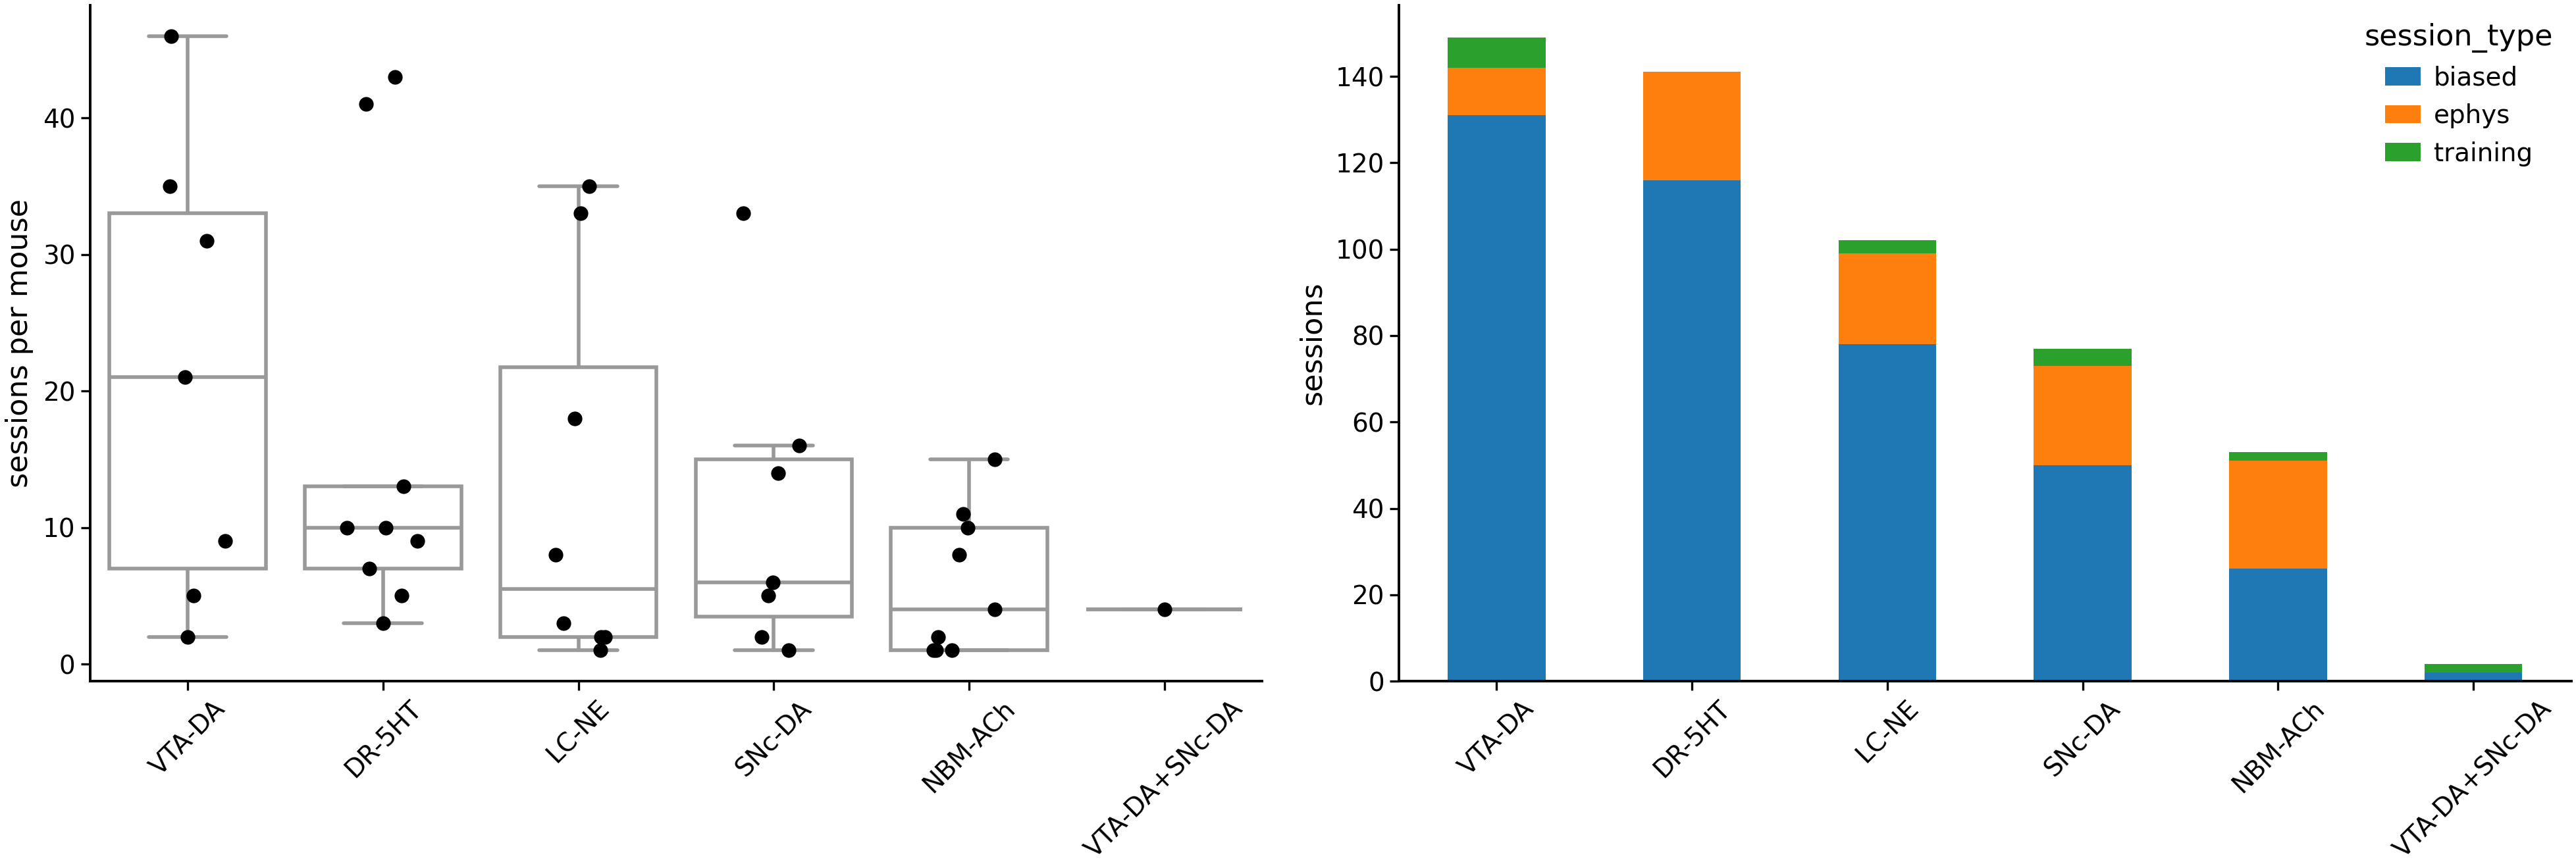

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
per_mouse = sessions.groupby(['NM', 'mouse_name']).size().rename('n').reset_index()
sns.stripplot(data=per_mouse, x='NM', y='n', order=nm_order, ax=axes[0], color='k', size=4, jitter=.2)
sns.boxplot(data=per_mouse, x='NM', y='n', order=nm_order, ax=axes[0], color='w', fliersize=0)
axes[0].set(ylabel='sessions per mouse', xlabel='')
axes[0].tick_params(axis='x', rotation=45)

ct = pd.crosstab(sessions['NM'], sessions['session_type']).reindex(nm_order)
ct.plot.bar(stacked=True, ax=axes[1])
axes[1].set(ylabel='sessions', xlabel='')
axes[1].tick_params(axis='x', rotation=45)
sns.despine(); plt.tight_layout()

25 sessions without a start_time (not in the QC csv) are not shown


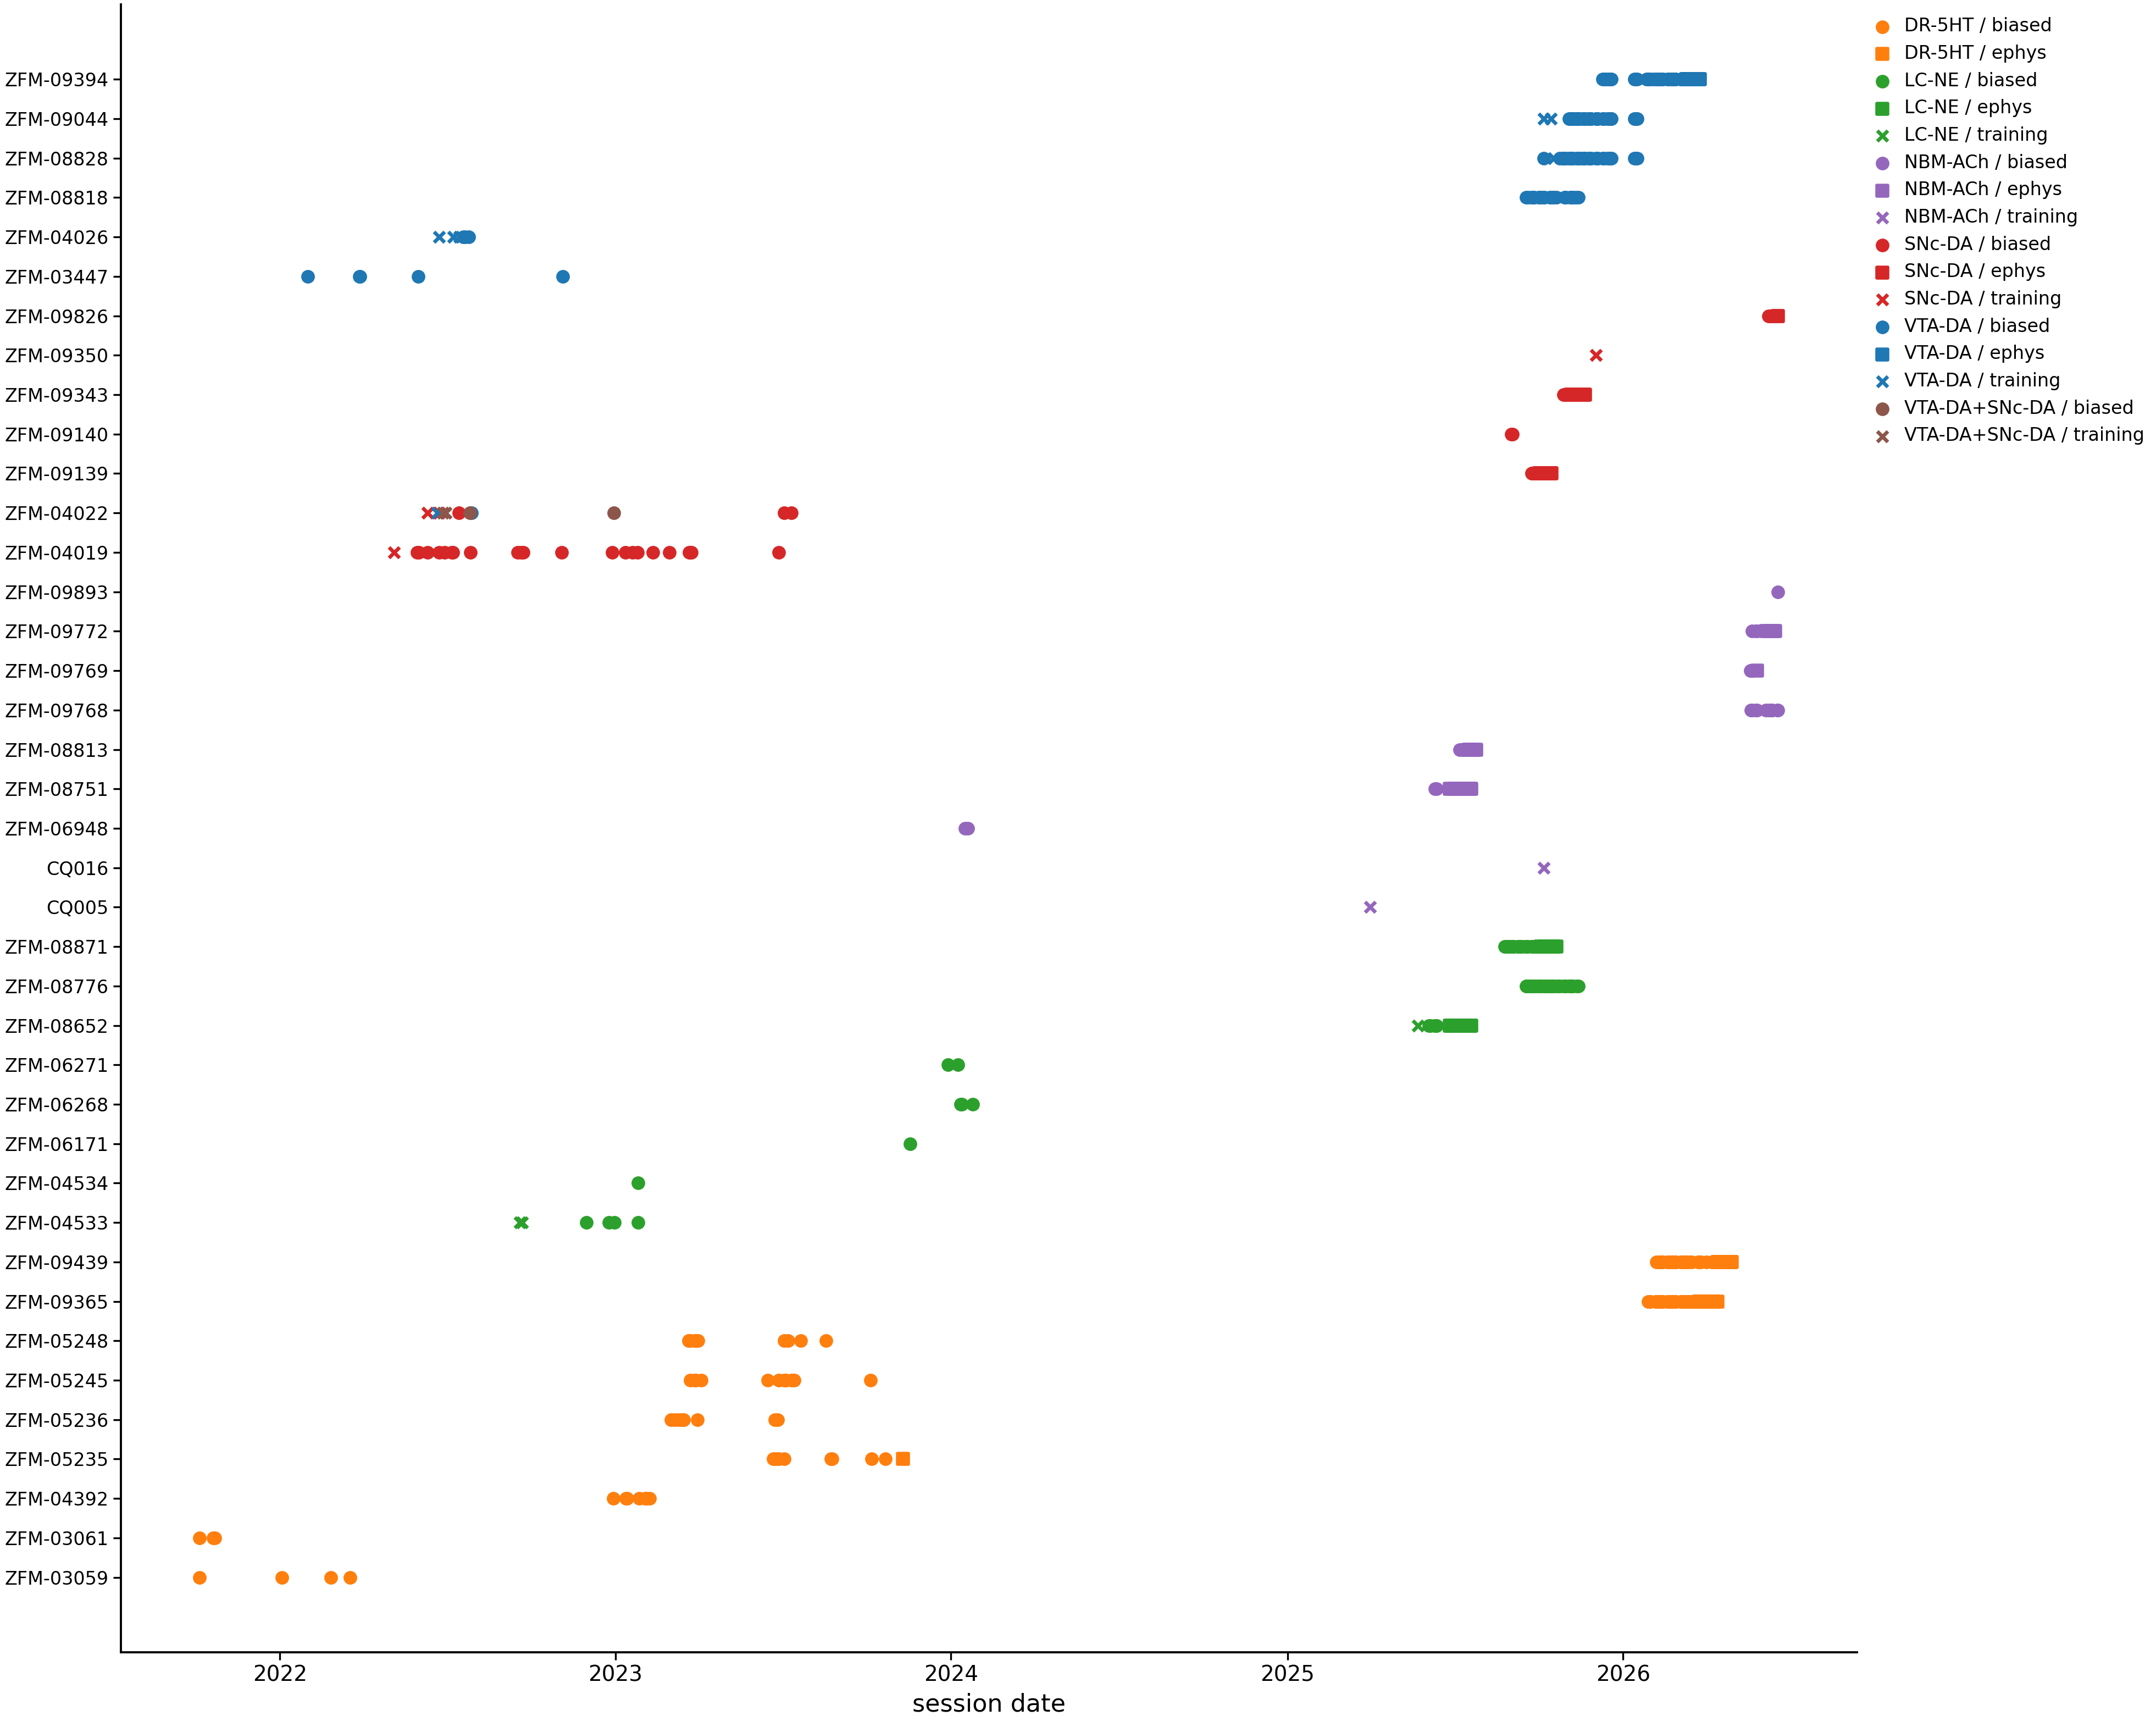

In [7]:
# Recording timeline: one row per mouse, coloured by NM, marker by protocol
tl = sessions.dropna(subset=['start_time']).sort_values(['NM', 'mouse_name'])
mice = tl['mouse_name'].unique()
ypos = {m: i for i, m in enumerate(mice)}
palette = dict(zip(nm_order, sns.color_palette('tab10', len(nm_order))))
markers = {'training': 'x', 'biased': 'o', 'ephys': 's'}

fig, ax = plt.subplots(figsize=(10, 0.18 * len(mice) + 1))
for (nm, st), g in tl.groupby(['NM', 'session_type']):
    ax.scatter(g['start_time'], g['mouse_name'].map(ypos), color=palette[nm], marker=markers.get(st, '.'),
               s=12, label=f'{nm} / {st}')
ax.set_yticks(range(len(mice)), mice, fontsize=6)
ax.legend(bbox_to_anchor=(1, 1), fontsize=6, frameon=False)
ax.set(xlabel='session date')
sns.despine(); plt.tight_layout()
print(f'{sessions["start_time"].isna().sum()} sessions without a start_time (not in the QC csv) are not shown')

## 3. Trial-level performance

One row per trial, taken from the states files (trial-level variables repeat over every bin of a trial).
- `block` = `probabilityLeft` (0.8 → left stimuli likely); `contrast` is unsigned
- **`choice` in the states/syllable files is mirrored**: `'right'` there is IBL `choice = +1`, which reports a
  *left* stimulus. It is relabelled below so `choice` = stimulus side reported. (`trial_type` in the syllable
  file carries the same mirrored label.)
- stimulus side is recovered from choice + outcome (correct → stimulus on the chosen side)
- `reaction` = first movement − go cue, `response` = response − go cue,
  `elongation` = go cue − quiescence period − trial start (how much the quiescence period was extended)

In [8]:
TRIAL_COLS = ['correct', 'choice', 'contrast', 'block', 'reaction', 'response', 'elongation', 'wsls',
              'trial_id', 'session']
trials = pd.concat([pd.read_parquet(f, columns=TRIAL_COLS)
                    .dropna(subset=['trial_id']).drop_duplicates('trial_id')
                    for f in sessions['states_file']], ignore_index=True)
trials = trials.rename(columns={'session': 'eid'}).merge(
    sessions[['eid', 'mouse_name', 'NM', 'transmitter', 'session_type']], on='eid')

flip = {'left': 'right', 'right': 'left'}
# The pipeline writes IBL choice == +1 as 'right', but +1 is the response to a LEFT stimulus
# (checked on raw ALF trials: correct & contrastLeft>0 -> choice +1). Relabel to the stimulus side reported.
trials['choice'] = trials['choice'].replace(flip)
trials['stim_side'] = np.where(trials['correct'] == 1, trials['choice'], trials['choice'].map(flip))
trials.loc[(trials['contrast'] == 0) | (trials['choice'] == 'no_go'), 'stim_side'] = np.nan
trials['signed_contrast'] = trials['contrast'] * trials['stim_side'].map({'left': -1, 'right': 1})
trials['right_choice'] = (trials['choice'] == 'right').astype(float)
trials.loc[trials['choice'] == 'no_go', 'right_choice'] = np.nan
print(trials.shape)
trials.isna().mean().round(4).to_frame('fraction NaN').T

(397472, 17)


,correct,choice,contrast,block,reaction,response,elongation,wsls,trial_id,eid,mouse_name,NM,transmitter,session_type,stim_side,signed_contrast,right_choice
fraction NaN,0.0,0.0,0.0,0.0,0.0051,0.0001,0.0001,0.0013,0.0,0.0,0.0,0.01,0.0,0.0,0.1781,0.1781,0.0039


In [9]:
# Sanity: blocks. Standard biased/ephys values are 0.2/0.5/0.8; anything else is unusual
trials['block'] = trials['block'].round(3)
odd = trials[~trials['block'].isin([0.2, 0.5, 0.8])]
print(f'{len(odd)} trials with non-standard probabilityLeft in {odd["eid"].nunique()} sessions')
print(trials['block'].value_counts().sort_index().to_string())

178 trials with non-standard probabilityLeft in 11 sessions
block
0.0         4
0.1        12
0.2    170400
0.3        31
0.4        42
0.5     56394
0.6        39
0.7        38
0.8    170500
0.9         7
1.0         5


In [10]:
def session_metrics(t):
    go = t[t['choice'] != 'no_go']
    zero = go[go['contrast'] == 0]
    p_right = zero.groupby('block')['right_choice'].mean()
    return pd.Series({
        'n_trials': len(t),
        'frac_correct': t['correct'].mean(),
        'frac_correct_easy': t.loc[t['contrast'] == 1, 'correct'].mean(),
        'frac_no_go': (t['choice'] == 'no_go').mean(),
        'frac_right': go['right_choice'].mean(),
        # block bias at 0% contrast: P(right | right-block) − P(right | left-block)
        'bias_shift_0': p_right.get(0.2, np.nan) - p_right.get(0.8, np.nan),
        'median_reaction': t['reaction'].median(),
        'median_response': t['response'].median(),
        'frac_slow_response': (t['response'] > 10).mean(),
        'median_elongation': t['elongation'].median(),
        'win_stay': (t['wsls'] == 'wst').sum() / t['wsls'].isin(['wst', 'wsh']).sum(),
        'lose_shift': (t['wsls'] == 'lsh').sum() / t['wsls'].isin(['lst', 'lsh']).sum(),
    })

perf = trials.groupby('eid')[[c for c in trials if c != 'eid']].apply(session_metrics).reset_index()
perf = sessions[['eid', 'mouse_name', 'NM', 'transmitter', 'session_type', 'start_time']].merge(perf, on='eid')
print(trials['wsls'].value_counts(dropna=False).to_string())
perf.describe().T.round(3)

wsls
wst     215720
wsh      85278
lst      58231
lsh      37710
None       533


,count,mean,min,25%,50%,75%,max,std
start_time,508,2025-04-14 18:01:45.666700288,2021-10-05 16:30:19.720909,2025-06-25 06:02:13.142793216,2025-10-28 11:08:44.457138688,2026-02-12 11:26:26.078479360,2026-06-18 10:54:56.886574,NaN
n_trials,533.0,745.726079,87.0,624.0,751.0,897.0,1374.0,219.022358
frac_correct,533.0,0.748279,0.382253,0.71256,0.758427,0.797337,0.906498,0.073712
frac_correct_easy,533.0,0.912462,0.5,0.885135,0.939759,0.968504,1.0,0.086102
frac_no_go,533.0,0.006931,0.0,0.0,0.0,0.003339,0.29661,0.022408
frac_right,533.0,0.454871,0.044554,0.35255,0.457912,0.546512,1.0,0.150502
bias_shift_0,512.0,0.248941,-0.340909,0.127373,0.246879,0.363978,0.713043,0.16743
median_reaction,533.0,0.423095,0.043307,0.157297,0.208516,0.34521,6.706554,0.716912
median_response,533.0,0.770247,0.19305,0.3352,0.4217,0.6513,22.56575,1.37632
frac_slow_response,533.0,0.04123,0.0,0.006682,0.015723,0.037787,0.610169,0.070651


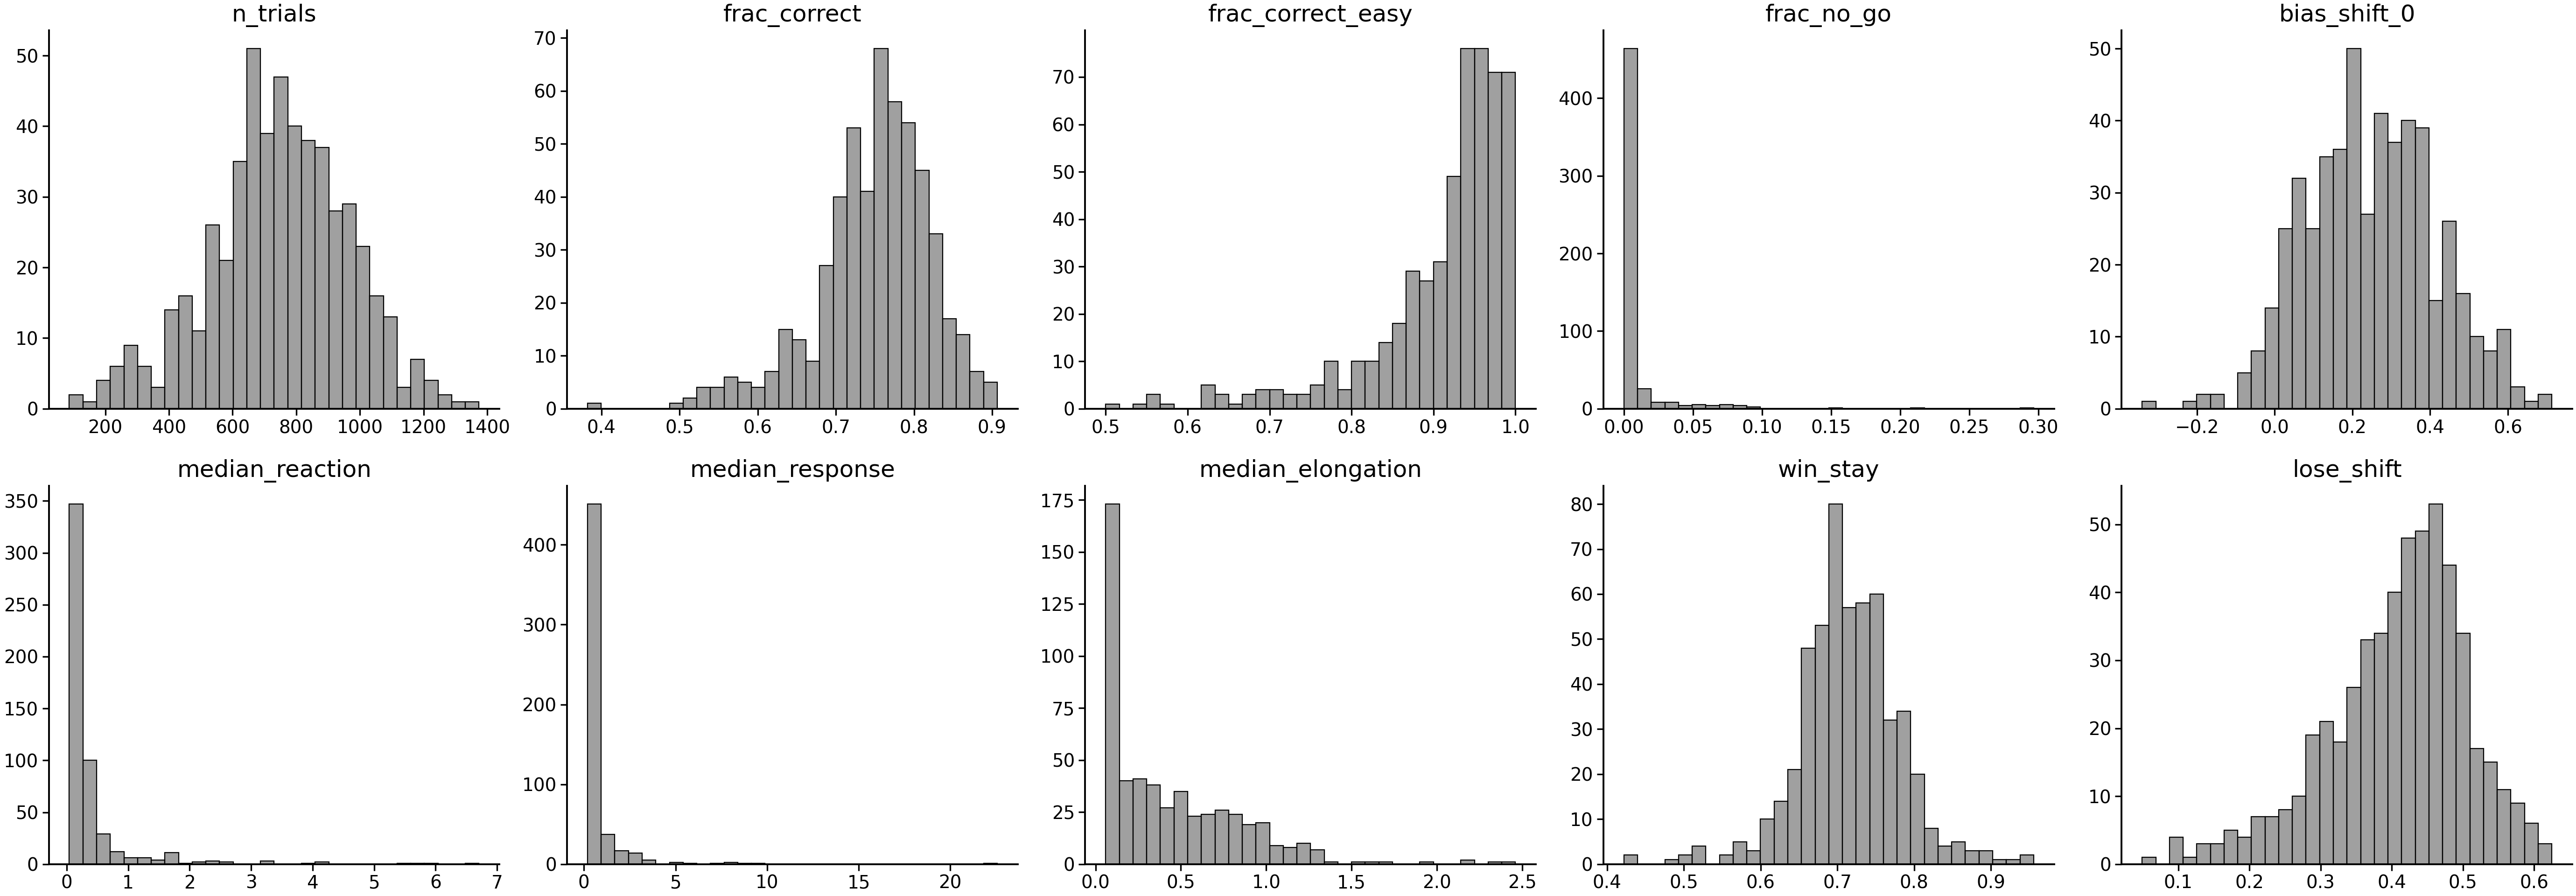

In [11]:
METRICS = ['n_trials', 'frac_correct', 'frac_correct_easy', 'frac_no_go', 'bias_shift_0',
           'median_reaction', 'median_response', 'median_elongation', 'win_stay', 'lose_shift']
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for ax, m in zip(axes.flat, METRICS):
    sns.histplot(perf[m], ax=ax, bins=30, color='grey')
    ax.set(title=m, xlabel='', ylabel='')
sns.despine(); plt.tight_layout()

In [12]:
# Training sessions have no blocks (bias_shift_0 is NaN) — summarise by protocol first
perf.groupby('session_type')[METRICS].median().round(3).T

session_type,biased,ephys,training
n_trials,741.500,831.000,607.500
frac_correct,0.746,0.811,0.746
frac_correct_easy,0.929,0.967,0.936
frac_no_go,0.000,0.000,0.002
bias_shift_0,0.233,0.273,NaN
median_reaction,0.228,0.179,0.235
median_response,0.438,0.370,0.631
median_elongation,0.307,0.438,0.289
win_stay,0.717,0.710,0.561
lose_shift,0.422,0.432,0.413


## 4. Per-NM comparison

Mice carry one NM target each, so NM is a between-mouse factor: the unit is the **mouse**,
not the session (each dot below = per-mouse median over its biased/ephys sessions).
Any NM difference here is behaviour of the mice that happened to get that implant, not an effect of the NM.

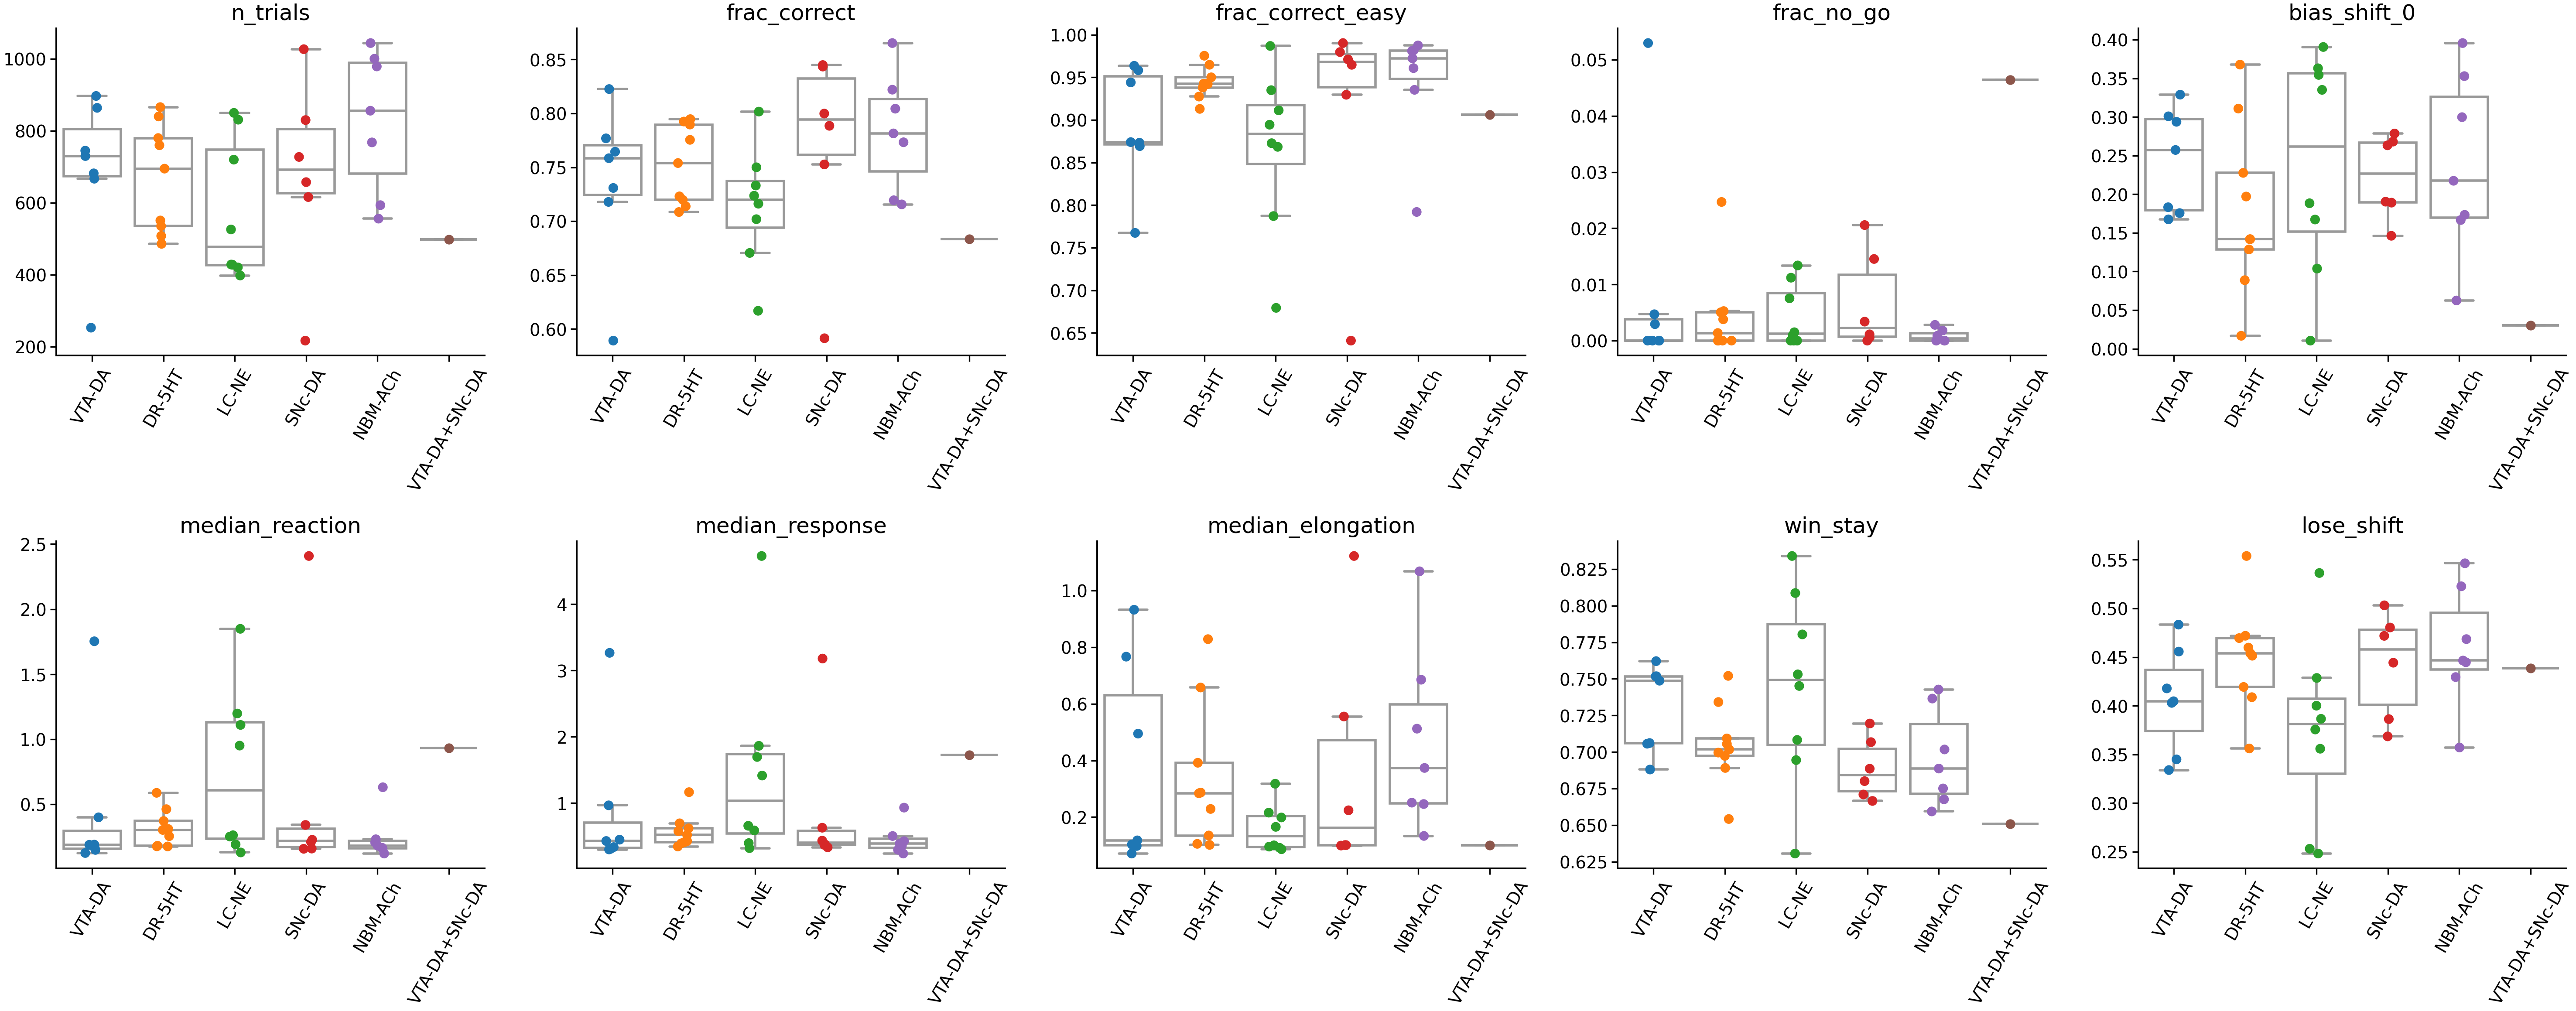

In [13]:
task = perf[perf['session_type'].isin(['biased', 'ephys'])]
per_mouse = task.groupby(['NM', 'mouse_name'])[METRICS].median().reset_index()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, m in zip(axes.flat, METRICS):
    sns.boxplot(data=per_mouse, x='NM', y=m, order=nm_order, ax=ax, color='w', fliersize=0)
    sns.stripplot(data=per_mouse, x='NM', y=m, order=nm_order, ax=ax, hue='NM', palette=palette,
                  size=4, legend=False)
    ax.set(title=m, xlabel='', ylabel='')
    ax.tick_params(axis='x', rotation=60, labelsize=7)
sns.despine(); plt.tight_layout()

In [14]:
from scipy.stats import kruskal
rows = []
for m in METRICS:
    groups = [g[m].dropna() for _, g in per_mouse.groupby('NM') if g[m].notna().sum() >= 3]
    rows.append({'metric': m, 'H': kruskal(*groups).statistic, 'p': kruskal(*groups).pvalue})
pd.DataFrame(rows).set_index('metric').round(4)  # NM groups with >=3 mice, mouse = unit, uncorrected

,H,p
metric,,
n_trials,6.1453,0.1886
frac_correct,6.1640,0.1872
frac_correct_easy,8.8105,0.0660
frac_no_go,2.3207,0.6770
bias_shift_0,2.1008,0.7172
median_reaction,5.0745,0.2797
median_response,5.8242,0.2127
median_elongation,7.2220,0.1246
win_stay,9.1634,0.0571


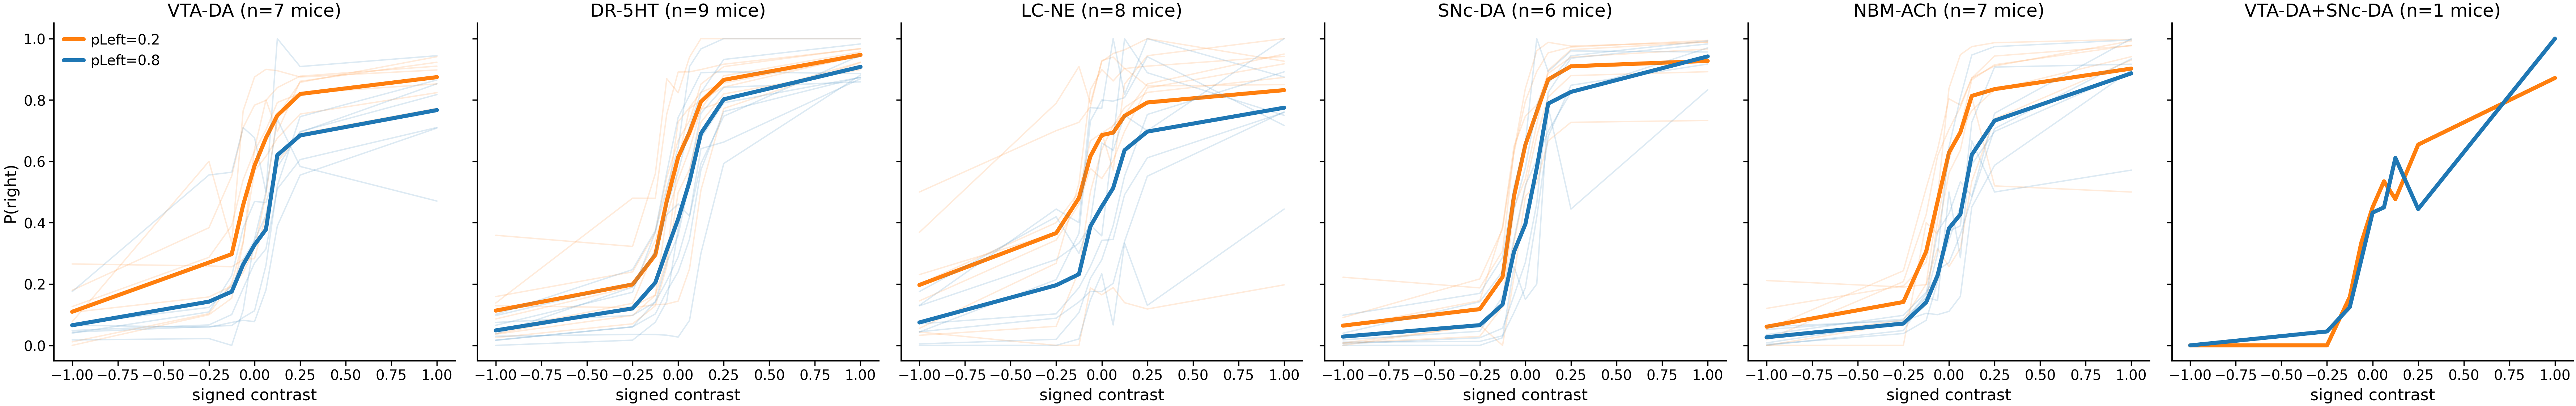

In [15]:
# Psychometric curves per NM (biased/ephys), split by block — mean over mice of per-mouse curves
go = trials[trials['session_type'].isin(['biased', 'ephys']) & (trials['choice'] != 'no_go')
            & trials['block'].isin([0.2, 0.8])].copy()
go['sc'] = go['signed_contrast'].fillna(0)  # 0% contrast has no side
curves = go.groupby(['NM', 'mouse_name', 'block', 'sc'])['right_choice'].mean().reset_index()

fig, axes = plt.subplots(1, len(nm_order), figsize=(3 * len(nm_order), 3), sharey=True)
for ax, nm in zip(np.atleast_1d(axes), nm_order):
    c = curves[curves['NM'] == nm]
    for block, col in [(0.2, 'tab:orange'), (0.8, 'tab:blue')]:
        cb = c[c['block'] == block]
        for _, g in cb.groupby('mouse_name'):
            ax.plot(g['sc'], g['right_choice'], color=col, alpha=.15, lw=.7)
        mean = cb.groupby('sc')['right_choice'].mean()
        ax.plot(mean.index, mean.values, color=col, lw=2, label=f'pLeft={block}')
    ax.set(title=f'{nm} (n={c["mouse_name"].nunique()} mice)', xlabel='signed contrast')
axes[0].set_ylabel('P(right)'); axes[0].legend(frameon=False, fontsize=7)
sns.despine(); plt.tight_layout()

## 5. Syllable file — first look

One row per (session, trial, epoch); `binned_sequence` holds the 10 syllable bins of that epoch,
`sample` = `"<eid> <trial_id>"`, `trial_type` = `"<outcome> <contrast> <block> <choice>"`.

In [16]:
syl = pd.read_parquet(SYLLABLE_FILE)
syl[['eid', 'trial_id']] = syl['sample'].str.split(' ', expand=True)
syl['trial_id'] = syl['trial_id'].astype(float)
print(syl.shape, '| sessions', syl['eid'].nunique(), '| mice', syl['mouse_name'].nunique())
print('same sessions as the states files:', set(syl['eid']) == set(sessions['eid']))
print('bins per sequence:', syl['binned_sequence'].str.len().value_counts().to_dict())
print(syl['broader_label'].value_counts().to_string())

(1586597, 7) | sessions 533 | mice 39
same sessions as the states files: True
bins per sequence: {10: 1586597}
broader_label
ITI               397352
Quiescence        396939
Pre-quiescence    396863
Choice            395443


In [17]:
# Trials that have a syllable row for every epoch vs trials in the states files
epochs_per_trial = syl.groupby(['eid', 'trial_id'])['broader_label'].nunique()
print('epochs per trial:', epochs_per_trial.value_counts().sort_index().to_dict())
cov = (syl.groupby('eid')['trial_id'].nunique() / trials.groupby('eid').size()).rename('frac_trials_with_syllables')
cov.describe().round(3)

epochs per trial: {1: 2, 2: 648, 3: 1981, 4: 394839}


count    533.000
mean       1.000
std        0.000
min        0.998
25%        1.000
50%        1.000
75%        1.000
max        1.000
Name: frac_trials_with_syllables, dtype: float64

NaN bins: 0.0116 | n syllables: 32


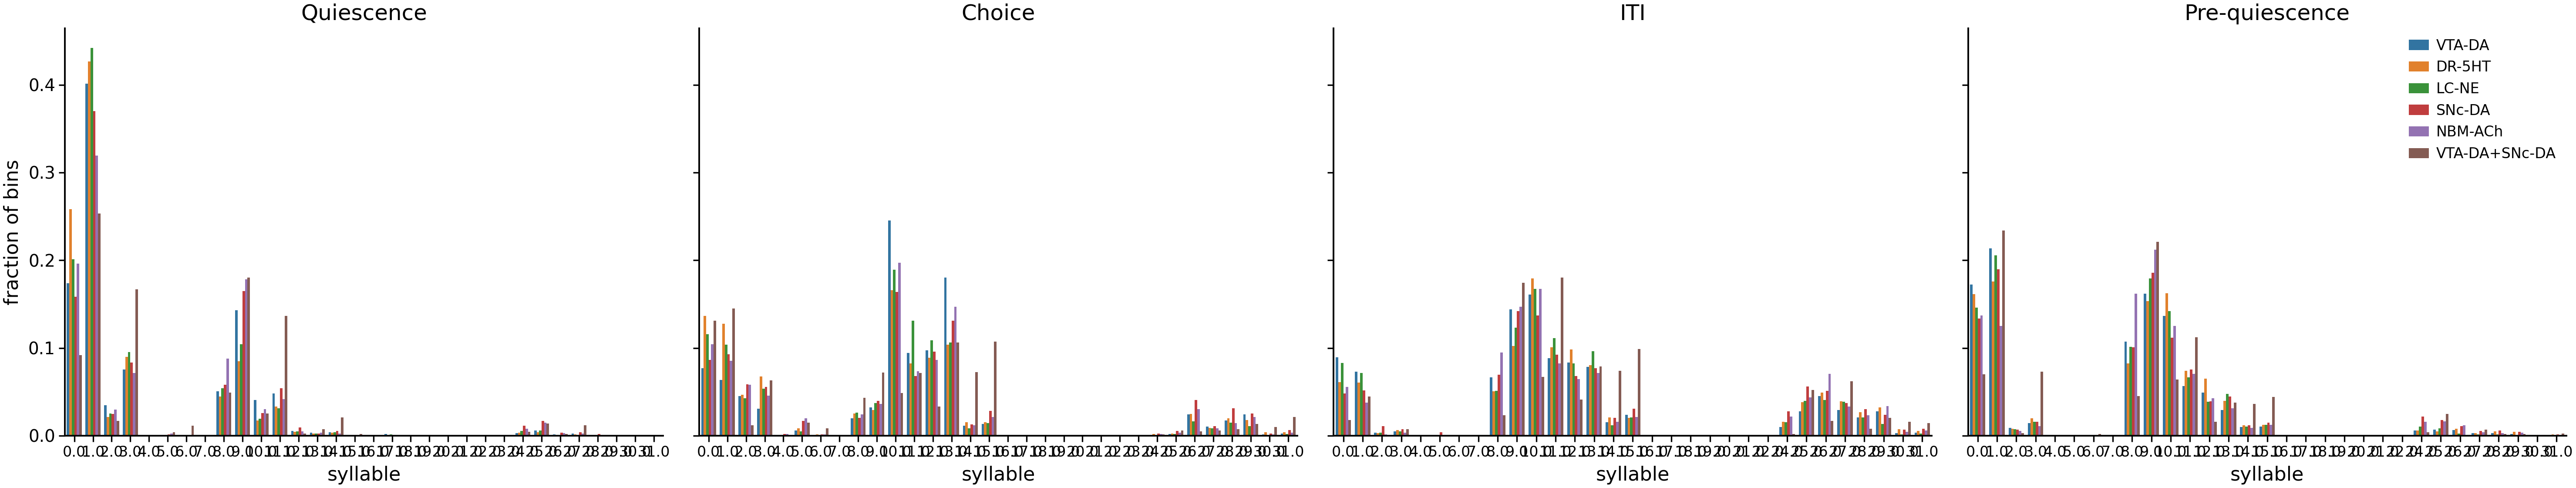

In [18]:
# Syllable usage per epoch (pooled bins) and per NM
seq = np.stack(syl['binned_sequence'].values)  # trials×epochs, 10 bins
flat = pd.DataFrame({'NM': np.repeat(syl['eid'].map(sessions.set_index('eid')['NM']).values, seq.shape[1]),
                     'broader_label': np.repeat(syl['broader_label'].values, seq.shape[1]),
                     'syllable': seq.ravel()})
print('NaN bins:', flat['syllable'].isna().mean().round(4), '| n syllables:', flat['syllable'].nunique())

epochs = ['Quiescence', 'Choice', 'ITI', 'Pre-quiescence']
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True)
for ax, ep in zip(axes, epochs):
    use = (flat[flat['broader_label'] == ep].groupby('NM')['syllable']
           .value_counts(normalize=True).rename('p').reset_index())
    sns.barplot(data=use, x='syllable', y='p', hue='NM', hue_order=nm_order, palette=palette, ax=ax)
    ax.set(title=ep, xlabel='syllable', ylabel='fraction of bins')
    ax.tick_params(axis='x', labelsize=6)
    if ax is not axes[-1]:
        ax.get_legend().remove()
axes[-1].legend(bbox_to_anchor=(1, 1), fontsize=6, frameon=False)
sns.despine(); plt.tight_layout()

## Next steps
- relate syllable usage/entropy to the trial metrics above, within mouse
- per-NM questions need the photometry traces aligned to trials (not in these files yet)